### 1. Setup e Imports

In [1]:
import json as _json
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import sys
from pathlib import Path
import subprocess

# Agregar path del proyecto para imports
sys.path.append(os.path.abspath('../../..'))
from sae.tools.naming_utils import save_checkpoint, get_model_name, get_extras_id, get_checkpoint_dir
from sae.tools.experiment_utils import get_experiment_dir, get_plots_dir, get_metrics_dir, get_report_name

# Configuración de visualización para Quarto/PDF
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(linewidth=100, precision=4, suppress=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')


Dispositivo: cuda


### 2 Metadata para Naming de Checkpoints

In [2]:
# Metadata para naming de checkpoints (separada de hiperparámetros)
NAMING_META = {
    'variante': 'matryoshkabatchtopk',    
    'tecnica':  'matryoshkabatchtopk',    
    'capa':     6,                        
    'juegos':   5000,                     
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',
    'experiment_base_path': os.path.abspath('../../../experiments'),
    'extras': {
        'expansion':         16,                  
        'k':                 81,                  
        'matryoshka_widths': [2048, 4096, 8192],  
        'epochs':            1000,
        'patience':          20,
        'lr':                1e-3
    }
}

print('\nMetadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


Metadata de naming:
  variante: matryoshkabatchtopk
  tecnica: matryoshkabatchtopk
  capa: 6
  juegos: 5000
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'k': 81, 'matryoshka_widths': [2048, 4096, 8192], 'epochs': 1000, 'patience': 20, 'lr': 0.001}


In [3]:
extras_id = get_extras_id(
    get_checkpoint_dir(
        NAMING_META['base_path'],
        NAMING_META['variante'],
        NAMING_META['tecnica'],
        NAMING_META['capa'],
        NAMING_META['juegos']
    ),
    NAMING_META['extras']
) if NAMING_META.get('extras') else None

# get_plots_dir crea el directorio automáticamente
plots_dir = Path(get_plots_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
))

print(f'extras_id: {extras_id}')
print(f'plots_dir: {plots_dir}')

✓ Nuevo extras registrado: ex2 → {'expansion': 16, 'k': 81, 'matryoshka_widths': [2048, 4096, 8192], 'epochs': 1000, 'patience': 20, 'lr': 0.001}
extras_id: ex2
plots_dir: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\ex2\plots


### 3. Configuración del SAE

**Arquitectura MatryoshkaBatchTopK:**
- **Nested reconstruction losses**: se calculan pérdidas MSE en múltiples sub-anchos (`matryoshka_widths`) — cada ancho debe reconstruir el input por sí solo
- **BatchTopK activation**: threshold global del batch para que el promedio de features activas sea `k`
- **Sin coeficiente de sparsidad**: la sparsity se controla directamente con `k`
- **Loss = Σ MSE(recon_w, x)** para cada ancho `w ∈ matryoshka_widths`

| Parámetro | L1 (standard) | BatchTopK | MatryoshkaBatchTopK |
|-----------|:---:|:---:|:---:|
| Sparsity | `sparsity_coef` (soft) | `k` (promedio del batch) | `k` (promedio, por nivel) |
| L0 | Variable | Variable por muestra | Variable por muestra, por nivel |
| Loss | MSE + λ·L1 | MSE | Σ MSE_width |

> Las celdas siguientes entrenan el SAE directamente sobre los archivos `.npy` pre-extraídos usando la arquitectura MatryoshkaBatchTopK.

In [4]:
NUM_EPOCHS = NAMING_META['extras']['epochs']

cfg = {
    'architecture':            'matryoshkabatchtopk',
    'd_in':                    512,
    'd_sae':                   8192,
    'k':                       81,
    'matryoshka_widths':       [2048, 4096, 8192],
    'lr':                      1e-3,
    'train_batch_size_tokens': 4096,
    'hook_name':               'blocks.5.hook_resid_post',
    # P3: betas según config.py de los autores (beta2=0.99 vs default PyTorch 0.999)
    'beta1':                   0.9,
    'beta2':                   0.99,
    # P1: parámetros para auxiliary loss de dead features (config.py de los autores)
    'n_batches_to_dead':       20,    # batches sin activación para declarar feature muerta
    'top_k_aux':               512,   # top-k features muertas usadas en L_aux
    'aux_penalty':             1/32,  # peso α de L_aux (paper ec. 5)
    # P2: normalización del input por muestra 
    'input_unit_norm':         True,
}

cfg_summary = pd.DataFrame({
    'Parámetro': ['architecture', 'd_in', 'd_sae', 'k (L0 promedio)', 'matryoshka_widths',
                  'hook_name', 'lr', 'beta1', 'beta2',
                  'n_batches_to_dead', 'top_k_aux', 'aux_penalty', 'input_unit_norm'],
    'Valor': [cfg['architecture'], cfg['d_in'], cfg['d_sae'], cfg['k'],
              str(cfg['matryoshka_widths']), cfg['hook_name'], cfg['lr'],
              cfg['beta1'], cfg['beta2'],
              cfg['n_batches_to_dead'], cfg['top_k_aux'], cfg['aux_penalty'],
              cfg['input_unit_norm']]
})
print('Configuración SAELens:')
print(cfg_summary.to_string(index=False))

Configuración SAELens:
        Parámetro                    Valor
     architecture      matryoshkabatchtopk
             d_in                      512
            d_sae                     8192
  k (L0 promedio)                       81
matryoshka_widths       [2048, 4096, 8192]
        hook_name blocks.5.hook_resid_post
               lr                    0.001
            beta1                      0.9
            beta2                     0.99
n_batches_to_dead                       20
        top_k_aux                      512
      aux_penalty                  0.03125
  input_unit_norm                     True


### 4. Dataset de Activaciones (Train/Validation Split 80-20%)

Activaciones pre-extraídas con `sae/activations/run_extraction.py` desde la capa `blocks.5.hook_resid_post`.


In [5]:
class ActivationsDataset(Dataset):
    """Dataset para cargar activaciones extraídas"""
    def __init__(self, activations_path):
        self.activations = np.load(activations_path, mmap_mode='r')
    def __len__(self):
        return len(self.activations)
    def __getitem__(self, idx):
        return torch.tensor(self.activations[idx], dtype=torch.float32)

activations_file = Path(f"../../../activations/data/layer{NAMING_META['capa']}_{NAMING_META['juegos']}games.npy")
full_dataset = ActivationsDataset(activations_file)

# Split 80-20 reproducible
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=cfg["train_batch_size_tokens"], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg["train_batch_size_tokens"], shuffle=False)

dataset_info = pd.DataFrame({
    'Conjunto': ['Train', 'Validación', 'Total'],
    'Muestras': [f'{len(train_dataset):,}', f'{len(val_dataset):,}', f'{len(full_dataset):,}'],
    'Shape':    [str(full_dataset.activations.shape), '', ''],
})
print(dataset_info.to_string(index=False))


  Conjunto Muestras         Shape
     Train  236,000 (295000, 512)
Validación   59,000              
     Total  295,000              


### 5. Modelo: MatryoshkaBatchTopK SAE

Implementación de la arquitectura MatryoshkaBatchTopK según el paper (ec. 3-5) y el código de los autores (`sae.py`).

**Arquitectura:**
- El encoder proyecta **una sola vez** con `W_enc` completo (`d_in → d_sae`) para obtener `f(x)` de tamaño `d_sae` (paper ec. 3)
- **BatchTopK global único**: se seleccionan los `k × batch_size` valores más altos sobre los `d_sae × batch_size` valores del batch completo — un único threshold compartido entre todos los anchos (paper ec. 6)
- Las reconstrucciones por nivel usan **prefijos del mismo vector**: `all_acts_topk[:, 0:w]` — las features `0:2048` son literalmente las mismas en el nivel `w=2048` y en el nivel `w=4096` (paper ec. 4)
- En **eval**, se usa un threshold persistente `θ` calibrado con EMA durante training — no se recalcula (paper ec. 7)
- **L0 es variable por muestra pero promedia ≈ k** en cada batch

| Parámetro | L1 (standard) | BatchTopK | MatryoshkaBatchTopK |
|-----------|:---:|:---:|:---:|
| Sparsity | `sparsity_coef` (soft) | `k` (promedio del batch) | `k` (promedio, threshold global) |
| L0 | Variable | Variable por muestra | Variable por muestra |
| Loss | MSE + λ·L1 | MSE | Σ MSE_width + α·L_aux |

In [6]:
class MatryoshkaBatchTopKSAE(nn.Module):
    """
    Sparse Autoencoder con activación MatryoshkaBatchTopK.
    Corregido según paper (ec. 3-5) e implementación de los autores (sae.py).

    Correcciones aplicadas:
    - P1: encoding único con W_enc completo; BatchTopK global; prefijos compartidos
    - P1: BatchTopK preserva valores originales (x * indicator), threshold EMA para eval
    - P1: auxiliary loss para dead features (sae.py:198-221)
    - P2: make_decoder_weights_and_grad_unit_norm proyecta gradiente (sae.py:51-57)
    - P2: preprocessing input_unit_norm configurable (sae.py:36-43)
    - P3: W_dec inicializado como transpuesta de W_enc (sae.py:93-94)
    """
    def __init__(self, d_in, d_sae, k, matryoshka_widths,
                 n_batches_to_dead=20, top_k_aux=512, aux_penalty=1/32,
                 input_unit_norm=False):
        super().__init__()
        self.d_in  = d_in
        self.d_sae = d_sae
        self.k     = k
        self.matryoshka_widths = sorted(matryoshka_widths)
        assert self.matryoshka_widths[-1] == d_sae, \
            f"El último ancho ({self.matryoshka_widths[-1]}) debe ser d_sae ({d_sae})"

        self.n_batches_to_dead = n_batches_to_dead
        self.top_k_aux         = top_k_aux
        self.aux_penalty       = aux_penalty
        self.input_unit_norm   = input_unit_norm

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        # P3: W_dec = W_enc^T normalizado (sae.py:93-94) — inicialización tied
        nn.init.kaiming_uniform_(self.W_enc)
        self.W_dec.data[:] = self.W_enc.t().data
        self.W_dec.data[:] = self.W_dec / self.W_dec.norm(dim=-1, keepdim=True)

        # P1: threshold persistente calibrado con EMA durante training (sae.py:97)
        self.register_buffer('threshold', torch.tensor(0.0))
        # P1: contador de batches sin activación por feature — para L_aux (sae.py:30-32)
        self.register_buffer('num_batches_not_active', torch.zeros(d_sae))

    # ------------------------------------------------------------------
    # P2: Preprocessing del input (sae.py:36-48)
    # ------------------------------------------------------------------

    def preprocess_input(self, x):
        if self.input_unit_norm:
            x_mean = x.mean(dim=-1, keepdim=True)
            x = x - x_mean
            x_std = x.std(dim=-1, keepdim=True)
            x = x / (x_std + 1e-5)
            return x, x_mean, x_std
        return x, None, None

    def postprocess_output(self, x_reconstruct, x_mean, x_std):
        if self.input_unit_norm and x_mean is not None:
            x_reconstruct = x_reconstruct * x_std + x_mean
        return x_reconstruct

    # ------------------------------------------------------------------
    # P1: Encoding único + BatchTopK global (sae.py:100-119)
    # ------------------------------------------------------------------

    def compute_activations(self, x_cent):
        # P1: encoding ÚNICO con W_enc completo — un solo pase para todos los anchos
        # Las features 0:w son literalmente las mismas en todos los niveles (paper ec. 3)
        pre_acts = x_cent @ self.W_enc     # [batch, d_sae]
        acts     = F.relu(pre_acts)         # ReLU antes del topk (sae.py:102)

        if self.training:
            # P1: BatchTopK global sobre d_sae×batch_size valores (paper ec. 6)
            # Preserva valores originales con scatter — NO resta threshold (sae.py:104-114)
            topk_result = torch.topk(acts.flatten(), self.k * x_cent.shape[0])
            acts_topk = (
                torch.zeros_like(acts.flatten())
                .scatter(-1, topk_result.indices, topk_result.values)
                .reshape(acts.shape)
            )
            self._update_threshold(acts_topk)
        else:
            # P1: eval usa threshold persistente, no recalcula (paper ec. 7, sae.py:117)
            acts_topk = torch.where(acts > self.threshold, acts, torch.zeros_like(acts))

        return acts, acts_topk

    @torch.no_grad()
    def _update_threshold(self, acts_topk, lr=0.01):
        # P1: EMA del mínimo valor positivo — calibra θ para eval (sae.py:224-228)
        positive_mask = acts_topk > 0
        if positive_mask.any():
            min_positive = acts_topk[positive_mask].min()
            self.threshold = (1 - lr) * self.threshold + lr * min_positive

    @torch.no_grad()
    def _update_inactive_features(self, acts_topk):
        # P1: necesario para L_aux — trackea qué features no se activan (sae.py:60-62)
        self.num_batches_not_active += (acts_topk.sum(0) == 0).float()
        self.num_batches_not_active[acts_topk.sum(0) > 0] = 0

    # ------------------------------------------------------------------
    # Forward
    # ------------------------------------------------------------------

    def forward(self, x):
        """
        Retorna:
            outputs      : lista de (recon_w, hidden_w) para cada ancho matryoshka
                           recon_w está en espacio normalizado (= espacio original si input_unit_norm=False)
            all_acts     : pre-topk [batch, d_sae] — para L_aux
            all_acts_topk: post-topk [batch, d_sae]
            x_proc       : x preprocesado (= x si input_unit_norm=False)
        """
        x_proc, x_mean, x_std = self.preprocess_input(x)
        x_cent = x_proc - self.b_dec
        all_acts, all_acts_topk = self.compute_activations(x_cent)

        # P1: reconstrucciones por PREFIJO compartido (paper ec. 4, sae.py:149-155)
        # all_acts_topk[:, 0:w] son las mismas features en todos los niveles anidados
        # recon_w se mantiene en espacio normalizado para que la loss compare espacios iguales
        outputs = []
        for w in self.matryoshka_widths:
            hidden_w = all_acts_topk[:, :w]
            recon_w  = hidden_w @ self.W_dec[:w, :] + self.b_dec
            outputs.append((recon_w, hidden_w))

        self._update_inactive_features(all_acts_topk)
        return outputs, all_acts, all_acts_topk, x_proc

    # ------------------------------------------------------------------
    # P1: Auxiliary loss para dead features (sae.py:198-221)
    # ------------------------------------------------------------------

    def get_auxiliary_loss(self, x_proc, x_reconstruct_full, all_acts):
        residual        = x_proc.float() - x_reconstruct_full.float()
        aux_reconstruct = torch.zeros_like(residual)

        dead_features = self.num_batches_not_active >= self.n_batches_to_dead

        if dead_features.sum() > 0:
            acts_topk_aux = torch.topk(
                all_acts[:, dead_features],
                min(self.top_k_aux, int(dead_features.sum())),
                dim=-1,
            )
            acts_aux = torch.zeros_like(all_acts[:, dead_features]).scatter(
                -1, acts_topk_aux.indices, acts_topk_aux.values
            )
            aux_reconstruct = aux_reconstruct + acts_aux @ self.W_dec[dead_features]

        if aux_reconstruct.abs().sum() > 0:
            return self.aux_penalty * (aux_reconstruct.float() - residual.float()).pow(2).mean()
        return torch.tensor(0.0, device=x_proc.device)

    # ------------------------------------------------------------------
    # P2: Constraint de norma unitaria con proyección del gradiente (sae.py:51-57)
    # ------------------------------------------------------------------

    @torch.no_grad()
    def make_decoder_weights_and_grad_unit_norm(self):
        # P2: proyecta gradiente al espacio tangente de la esfera unitaria + normaliza
        # @torch.no_grad() evita trazar grafo interno — no impide leer .grad (sae.py:50)
        # Llamar ANTES de optimizer.step() (training.py:31)
        W_dec_normed    = self.W_dec / self.W_dec.norm(dim=-1, keepdim=True)
        W_dec_grad_proj = (
            (self.W_dec.grad * W_dec_normed).sum(-1, keepdim=True) * W_dec_normed
        )
        self.W_dec.grad -= W_dec_grad_proj
        self.W_dec.data  = W_dec_normed


# Crear modelo
model = MatryoshkaBatchTopKSAE(
    d_in=cfg['d_in'],
    d_sae=cfg['d_sae'],
    k=cfg['k'],
    matryoshka_widths=cfg['matryoshka_widths'],
    n_batches_to_dead=cfg['n_batches_to_dead'],
    top_k_aux=cfg['top_k_aux'],
    aux_penalty=cfg['aux_penalty'],
    input_unit_norm=cfg['input_unit_norm'],
).to(device)
num_params = sum(p.numel() for p in model.parameters())

model_info = pd.DataFrame({
    'Componente': [
        'Input', 'Encoder (W_enc)', 'Activación', 'Anchos matryoshka',
        'Hidden activos (por nivel)', 'Decoder (W_dec)', 'Output', 'Total params'
    ],
    'Dimensión': [
        f'{cfg["d_in"]}',
        f'{cfg["d_in"]} -> {cfg["d_sae"]} (único pase, prefijos compartidos)',
        f'BatchTopK global (k={cfg["k"]}) — threshold EMA en eval',
        str(cfg['matryoshka_widths']),
        f'≈ {cfg["k"]} activos (promedio del batch)',
        f'{cfg["d_sae"]} -> {cfg["d_in"]} (slices de prefijo)',
        f'{cfg["d_in"]}',
        f'{num_params:,}'
    ]
})
print(model_info.to_string(index=False))

                Componente                                       Dimensión
                     Input                                             512
           Encoder (W_enc)  512 -> 8192 (único pase, prefijos compartidos)
                Activación BatchTopK global (k=81) — threshold EMA en eval
         Anchos matryoshka                              [2048, 4096, 8192]
Hidden activos (por nivel)               ≈ 81 activos (promedio del batch)
           Decoder (W_dec)                 8192 -> 512 (slices de prefijo)
                    Output                                             512
              Total params                                       8,389,120


### 6. Función de Pérdida MatryoshkaBatchTopK

**Loss = mean MSE(recon_w, x) para cada ancho w ∈ matryoshka_widths + α·L_aux**

- **MSE en cada nivel**: error de reconstrucción desde cada sub-espacio matryoshka
- **Sin L1 penalty**: la sparsity está controlada por el threshold global de BatchTopK
- **Loss total = media de MSE en todos los anchos** — mantiene la escala estable y preserva el balance entre reconstrucción y aux_loss independientemente del número de anchos (alineado con Bussmann `sae.py:172`)
- La loss anidada fuerza a que los sub-espacios más pequeños también sean representaciones completas del input

In [7]:
def loss_function(x_proc, outputs, all_acts, model):
    """
    Pérdida MatryoshkaBatchTopK: media de MSE en cada ancho + auxiliary loss.

    Paper ec. 5: L(x) = Σ_{m∈M} ‖x - x̂ₘ‖² + α·L_aux
    Bussmann (sae.py): promedia dividiendo por n_grupos — mantiene la escala de
    la MSE estable independientemente del número de anchos, y preserva el balance
    entre reconstrucción y aux_loss.

    Args:
        x_proc:  activaciones preprocesadas [batch, d_in] (= x si input_unit_norm=False)
        outputs: lista de (recon_w, hidden_w) por ancho matryoshka
        all_acts: activaciones pre-topk [batch, d_sae] — para L_aux
        model:   referencia al modelo (para get_auxiliary_loss)
    Returns:
        total_loss, mse_per_width, aux_loss
    """
    x_reconstruct_full = outputs[-1][0]   # reconstrucción del ancho máximo

    # Media de MSE en todos los anchos + término b_dec (alineado con Bussmann sae.py:163-172)
    mse_bdec      = F.mse_loss(model.b_dec.expand_as(x_proc), x_proc)
    mse_per_width = [F.mse_loss(recon_w, x_proc) for recon_w, _ in outputs]
    mean_mse      = (mse_bdec + sum(mse_per_width)) / (len(mse_per_width) + 1)

    # P1: auxiliary loss para dead features (paper ec. 5: α·L_aux, sae.py:198-221)
    aux_loss = model.get_auxiliary_loss(x_proc, x_reconstruct_full, all_acts)

    return mean_mse + aux_loss, mse_per_width, aux_loss


# P3: betas según config.py de los autores — beta2=0.99 vs default PyTorch 0.999
# (config.py: beta1=0.9, beta2=0.99)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], cfg["beta2"])
)

optim_info = pd.DataFrame({
    'Parámetro': ['Optimizador', 'lr', 'beta1', 'beta2',
                  'k (L0 promedio)', 'Anchos matryoshka',
                  'aux_penalty', 'n_batches_to_dead', 'top_k_aux'],
    'Valor':     ['Adam', cfg["lr"], cfg["beta1"], cfg["beta2"],
                  cfg["k"], str(cfg['matryoshka_widths']),
                  cfg['aux_penalty'], cfg['n_batches_to_dead'], cfg['top_k_aux']]
})
print(optim_info.to_string(index=False))

        Parámetro              Valor
      Optimizador               Adam
               lr              0.001
            beta1                0.9
            beta2               0.99
  k (L0 promedio)                 81
Anchos matryoshka [2048, 4096, 8192]
      aux_penalty            0.03125
n_batches_to_dead                 20
        top_k_aux                512


### 7. Loop de Entrenamiento

In [8]:
PATIENCE = NAMING_META['extras']['patience']
WIDTHS   = cfg['matryoshka_widths']

save_dir = Path('./saved_model')
save_dir.mkdir(exist_ok=True)
best_model_name = get_model_name(
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='best',
    extras_id=extras_id
)
BEST_CKPT = save_dir / best_model_name

history = {
    'train_total_loss':      [],
    'train_aux_loss':        [],
    'train_l0_sparsity':     [],
    'train_fraction_active': [],
    'val_total_loss':        [],
    'val_aux_loss':          [],
    'val_l0_sparsity':       [],
    'val_fraction_active':   [],
}
for w in WIDTHS:
    history[f'val_mse_w{w}'] = []

best_val_loss     = float('inf')
best_epoch        = 0
epochs_no_improve = 0

print(f'Iniciando entrenamiento: {NUM_EPOCHS} épocas máximo')
print(f'Early stopping: patience={PATIENCE}')
print(f'k = {cfg["k"]} features activas (L0 promedio ≈ k por batch)')
print(f'Anchos matryoshka: {WIDTHS}')
print(f'Best checkpoint: {BEST_CKPT}')
print('=' * 70)

for epoch in range(NUM_EPOCHS):

    # ------------------------------------------------------------------ TRAIN
    model.train()
    t_total = t_aux = t_l0 = t_frac = 0.0

    for batch in train_loader:
        x = batch.to(device)
        optimizer.zero_grad()

        # P1: forward devuelve (outputs, all_acts, all_acts_topk, x_proc)
        outputs, all_acts, all_acts_topk, x_proc = model(x)
        total_loss, _, aux_loss_val = loss_function(x_proc, outputs, all_acts, model)
        total_loss.backward()

        # P2: proyectar gradiente al espacio tangente de la esfera + normalizar
        # ANTES de optimizer.step() (sae.py:51-57, training.py:31)
        model.make_decoder_weights_and_grad_unit_norm()
        optimizer.step()
        # REMOVED: model.normalize_decoder() — reemplazado por make_decoder_weights_and_grad_unit_norm

        with torch.no_grad():
            hidden_full = outputs[-1][1]
            t_total += total_loss.item()
            t_aux   += aux_loss_val.item()
            t_l0    += (hidden_full > 0).float().sum(dim=1).mean().item()
            t_frac  += (hidden_full > 0).float().mean().item()

    n = len(train_loader)
    history['train_total_loss'].append(t_total / n)
    history['train_aux_loss'].append(t_aux / n)
    history['train_l0_sparsity'].append(t_l0 / n)
    history['train_fraction_active'].append(t_frac / n)

    # ---------------------------------------------------------------- VALIDATION
    model.eval()
    v_total = v_aux = v_l0 = v_frac = 0.0
    v_per_width = {w: 0.0 for w in WIDTHS}

    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            outputs, all_acts, all_acts_topk, x_proc = model(x)
            total_loss, mse_per_width, aux_loss_val = loss_function(x_proc, outputs, all_acts, model)
            hidden_full = outputs[-1][1]

            v_total += total_loss.item()
            v_aux   += aux_loss_val.item()
            v_l0    += (hidden_full > 0).float().sum(dim=1).mean().item()
            v_frac  += (hidden_full > 0).float().mean().item()
            for w, mse_w in zip(WIDTHS, mse_per_width):
                v_per_width[w] += mse_w.item()

    nv = len(val_loader)
    history['val_total_loss'].append(v_total / nv)
    history['val_aux_loss'].append(v_aux / nv)
    history['val_l0_sparsity'].append(v_l0 / nv)
    history['val_fraction_active'].append(v_frac / nv)
    for w in WIDTHS:
        history[f'val_mse_w{w}'].append(v_per_width[w] / nv)

    width_str = ' | '.join(f'w{w}={history[f"val_mse_w{w}"][-1]:.4f}' for w in WIDTHS)
    print(f"Época {epoch+1:3d}/{NUM_EPOCHS} | "
          f"Train: {history['train_total_loss'][-1]:.6f} | "
          f"Val: {history['val_total_loss'][-1]:.6f} | "
          f"L_aux: {history['val_aux_loss'][-1]:.6f} | "
          f"L0: {history['val_l0_sparsity'][-1]:.1f} | "
          f"{width_str}")

    # Early stopping (basado en loss total de validación)
    if history['val_total_loss'][-1] < best_val_loss - 1e-4:
        best_val_loss     = history['val_total_loss'][-1]
        best_epoch        = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT)
        save_checkpoint(
            model,
            base_path=NAMING_META['base_path'],
            variante=NAMING_META['variante'],
            tecnica=NAMING_META['tecnica'],
            capa=NAMING_META['capa'],
            juegos=NAMING_META['juegos'],
            estado='best',
            extras=NAMING_META['extras'],
            config=cfg,
            history=history,
            optimizer=optimizer
        )
        print(f'  Mejor modelo guardado (época {best_epoch} | Val Loss: {best_val_loss:.6f})')

    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping en época {epoch+1} (mejor: época {best_epoch})')
            break

# Restaurar mejor modelo
model.load_state_dict(torch.load(BEST_CKPT, weights_only=True))
print(f'\nMejor época: {best_epoch} | Mejor Val Loss: {best_val_loss:.6f}')

Iniciando entrenamiento: 1000 épocas máximo
Early stopping: patience=20
k = 81 features activas (L0 promedio ≈ k por batch)
Anchos matryoshka: [2048, 4096, 8192]
Best checkpoint: saved_model\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_best.pt
Época   1/1000 | Train: 0.570653 | Val: 1.997144 | L_aux: 0.000000 | L0: 953.0 | w2048=0.9757 | w4096=2.0018 | w8192=4.0269
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_best.pt
  Mejor modelo guardado (época 1 | Val Loss: 1.997144)
Época   2/1000 | Train: 0.485447 | Val: 0.605642 | L_aux: 0.000000 | L0: 284.5 | w2048=0.3316 | w4096=0.4530 | w8192=0.6640
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6

### 8. Guardar Modelo

In [9]:
# Guardar checkpoint final
checkpoint = {
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': {
        'architecture':      cfg['architecture'],
        'd_in':              cfg['d_in'],
        'd_sae':             cfg['d_sae'],
        'k':                 cfg['k'],
        'matryoshka_widths': cfg['matryoshka_widths'],
        'lr':                cfg['lr'],
        'hook_name':         cfg['hook_name'],
    },
    'history': history,
}

final_model_name = get_model_name(
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    extras_id=extras_id
)
checkpoint_path = save_dir / final_model_name
torch.save(checkpoint, checkpoint_path)
print(f'Modelo guardado: {checkpoint_path}')

save_checkpoint(
    model,
    base_path=NAMING_META['base_path'],
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    extras=NAMING_META['extras'],
    config=cfg,
    history=history,
    optimizer=optimizer
)

Modelo guardado: saved_model\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_final.pt
✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_final.pt


WindowsPath('C:/Users/Esposa/Documents/Repos/sae-othello-gpt/layer_06/models/sae_matryoshkabatchtopk/sae_matryoshkabatchtopk_matryoshkabatchtopk/5000games/sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_final.pt')

### 9. Métricas básicas del modelo

In [10]:
metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

training_metrics = {
    # Calidad de reconstrucción (loss total = media de MSE en todos los anchos)
    'val_total_loss_final':      history['val_total_loss'][-1],
    'val_total_loss_best':       best_val_loss,
    # MSE por ancho matryoshka (último epoch)
    **{f'val_mse_w{w}_final': history[f'val_mse_w{w}'][-1] for w in WIDTHS},
    # Sparsity (L0 del ancho máximo)
    'val_l0_final':              history['val_l0_sparsity'][-1],
    'val_fraction_active_final': history['val_fraction_active'][-1],
    # Contexto del entrenamiento
    'best_epoch':                best_epoch,
    'total_epochs':              len(history['train_total_loss']),
    'train_total_loss_final':    history['train_total_loss'][-1],
    'train_l0_final':            history['train_l0_sparsity'][-1],
    # Hiperparámetros MatryoshkaBatchTopK
    'architecture':              cfg['architecture'],
    'k':                         cfg['k'],
    'matryoshka_widths':         cfg['matryoshka_widths'],
    'd_sae':                     cfg['d_sae'],
    'd_in':                      cfg['d_in'],
    'expansion_factor':          cfg['d_sae'] // cfg['d_in'],
    'hook_name':                 cfg['hook_name'],
}

os.makedirs(metrics_dir, exist_ok=True)
metrics_path = Path(metrics_dir) / 'training_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(training_metrics, f, indent=2)

print(f'Métricas guardadas: {metrics_path}')
print(pd.DataFrame(
    list(training_metrics.items()), columns=['Métrica', 'Valor']
).to_string(index=False))

Métricas guardadas: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\ex2\metrics\training_metrics.json
                  Métrica                    Valor
     val_total_loss_final                 0.409588
      val_total_loss_best                 0.409655
      val_mse_w2048_final                  0.25093
      val_mse_w4096_final                 0.224211
      val_mse_w8192_final                 0.209287
             val_l0_final                80.540218
val_fraction_active_final                 0.009832
               best_epoch                      147
             total_epochs                      167
   train_total_loss_final                 0.386052
           train_l0_final                     81.0
             architecture      matryoshkabatchtopk
                        k                       81
        matryoshka_widths       [2048, 4096, 8192]
                    d_sae       

### 10. Visualización de Resultados

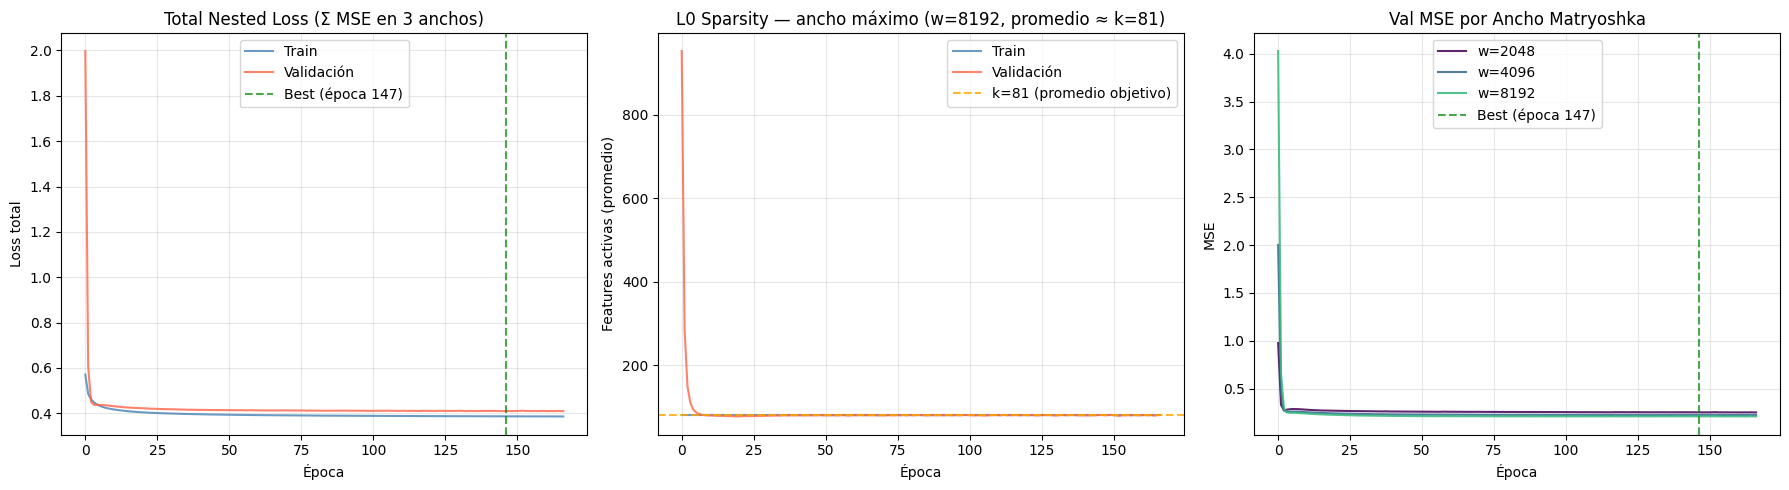


Gráficas guardadas exitosamente


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Nested Loss
axes[0].plot(history['train_total_loss'], label='Train', color='steelblue', alpha=0.8)
axes[0].plot(history['val_total_loss'],   label='Validación', color='tomato', alpha=0.8)
if best_epoch > 0:
    axes[0].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7,
                    label=f'Best (época {best_epoch})')
axes[0].set_title(f'Total Nested Loss (Σ MSE en {len(WIDTHS)} anchos)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss total')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# L0 sparsity (ancho máximo, L0 promedio ≈ k)
axes[1].plot(history['train_l0_sparsity'], label='Train', color='steelblue', alpha=0.8)
axes[1].plot(history['val_l0_sparsity'],   label='Validación', color='tomato', alpha=0.8)
axes[1].axhline(cfg["k"], color='orange', linestyle='--', alpha=0.8,
                label=f'k={cfg["k"]} (promedio objetivo)')
axes[1].set_title(f'L0 Sparsity — ancho máximo (w={cfg["d_sae"]}, promedio ≈ k={cfg["k"]})')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Features activas (promedio)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MSE por ancho matryoshka (validación)
colors_w = plt.cm.viridis([i / len(WIDTHS) for i in range(len(WIDTHS))])
for w, color in zip(WIDTHS, colors_w):
    axes[2].plot(history[f'val_mse_w{w}'], label=f'w={w}', color=color, alpha=0.85)
if best_epoch > 0:
    axes[2].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7,
                    label=f'Best (época {best_epoch})')
axes[2].set_title('Val MSE por Ancho Matryoshka')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('MSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print('Gráficas guardadas exitosamente')
print('='*50)

### 12. Generar PDF con Quarto

Una vez ejecutado todo el notebook, ejecutar el siguiente comando en la terminal para generar el PDF con Quarto:

In [13]:
exp_dir = get_experiment_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'training',
    extras_id=extras_id
)

notebook_name = 'train_sae_matryoska-batch-topk.ipynb'
output_path = exp_dir / pdf_name

print(f'Generando PDF con Quarto...')
print(f'Archivo de salida: {output_path}')

# Quarto no acepta rutas en --output, solo nombre de archivo
# Se usa --output-dir para el directorio y --output solo para el nombre
result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{exp_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f'PDF generado exitosamente: {output_path}')
else:
    print(f'Error al generar PDF:')
    print(result.stderr)

Generando PDF con Quarto...
Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\ex2\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_training.pdf
PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_matryoshkabatchtopk\sae_matryoshkabatchtopk_matryoshkabatchtopk\5000games\ex2\sae_matryoshkabatchtopk_matryoshkabatchtopk_l6_5000g_ex2_training.pdf
